In [584]:

import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [585]:
df = pd.read_csv('loan_approval_dataset.csv')

In [586]:
df.head()

,loan_id,no_of_dependents,education,self_employed,income_annum,loan_amount,loan_term,cibil_score,residential_assets_value,commercial_assets_value,luxury_assets_value,bank_asset_value,loan_status
0,1,2,Graduate,No,9600000,29900000,12,778,2400000,17600000,22700000,8000000,Approved
1,2,0,Not Graduate,Yes,4100000,12200000,8,417,2700000,2200000,8800000,3300000,Rejected
2,3,3,Graduate,No,9100000,29700000,20,506,7100000,4500000,33300000,12800000,Rejected
3,4,3,Graduate,No,8200000,30700000,8,467,18200000,3300000,23300000,7900000,Rejected
4,5,5,Not Graduate,Yes,9800000,24200000,20,382,12400000,8200000,29400000,5000000,Rejected


In [587]:
df.columns = df.columns.str.strip()

In [588]:
df.describe()

,loan_id,no_of_dependents,income_annum,loan_amount,loan_term,cibil_score,residential_assets_value,commercial_assets_value,luxury_assets_value,bank_asset_value
count,4269.000000,4269.000000,4.269000e+03,4.269000e+03,4269.000000,4269.000000,4.269000e+03,4.269000e+03,4.269000e+03,4.269000e+03
mean,2135.000000,2.498712,5.059124e+06,1.513345e+07,10.900445,599.936051,7.472617e+06,4.973155e+06,1.512631e+07,4.976692e+06
std,1232.498479,1.695910,2.806840e+06,9.043363e+06,5.709187,172.430401,6.503637e+06,4.388966e+06,9.103754e+06,3.250185e+06
min,1.000000,0.000000,2.000000e+05,3.000000e+05,2.000000,300.000000,-1.000000e+05,0.000000e+00,3.000000e+05,0.000000e+00
25%,1068.000000,1.000000,2.700000e+06,7.700000e+06,6.000000,453.000000,2.200000e+06,1.300000e+06,7.500000e+06,2.300000e+06
50%,2135.000000,3.000000,5.100000e+06,1.450000e+07,10.000000,600.000000,5.600000e+06,3.700000e+06,1.460000e+07,4.600000e+06
75%,3202.000000,4.000000,7.500000e+06,2.150000e+07,16.000000,748.000000,1.130000e+07,7.600000e+06,2.170000e+07,7.100000e+06
max,4269.000000,5.000000,9.900000e+06,3.950000e+07,20.000000,900.000000,2.910000e+07,1.940000e+07,3.920000e+07,1.470000e+07


In [589]:
df.isna().sum().sort_values(ascending=False)

loan_id                     0
no_of_dependents            0
education                   0
self_employed               0
income_annum                0
loan_amount                 0
loan_term                   0
cibil_score                 0
residential_assets_value    0
commercial_assets_value     0
luxury_assets_value         0
bank_asset_value            0
loan_status                 0
dtype: int64

In [590]:
df.drop("loan_id", axis=1, inplace=True)

In [ ]:
df.columns = [
    'dependents',
    'education',
    'self_employed',
    'annual_income',
    'loan_amount',
    'loan_term',
    'cibil_score',
    'residential_assets',
    'commercial_assets',
    'luxury_assets',
    'bank_assets',
    'loan_status'
]

In [591]:
df['loan_status'].value_counts(normalize=True)

loan_status
Approved    0.62216
Rejected    0.37784
Name: proportion, dtype: float64

<Axes: xlabel='loan_status', ylabel='count'>

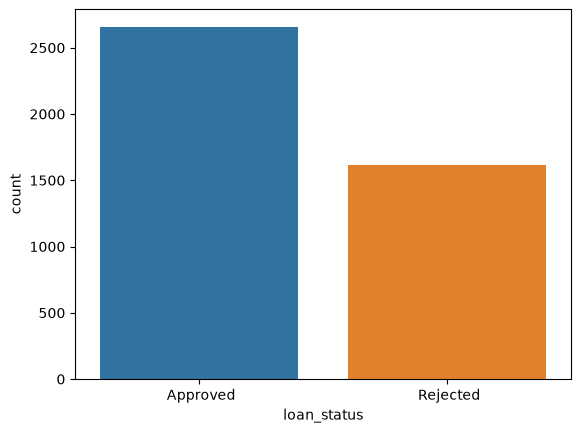

In [592]:
sns.countplot(data=df,x = df['loan_status'],hue='loan_status')

<Axes: xlabel='income_annum', ylabel='Density'>

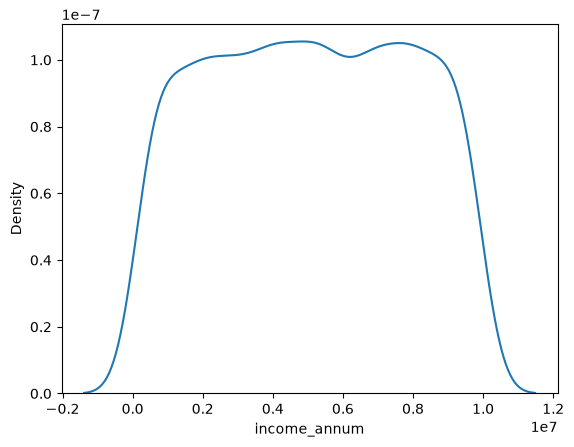

In [593]:
sns.kdeplot(data=df,x=df['income_annum'])

In [594]:
for col in str_cols:
    print(f"\n===== {col} =====")
    print(df[col].value_counts())


===== education =====
education
Graduate        2144
Not Graduate    2125
Name: count, dtype: int64

===== self_employed =====
self_employed
Yes    2150
No     2119
Name: count, dtype: int64

===== loan_status =====
loan_status
Approved    2656
Rejected    1613
Name: count, dtype: int64


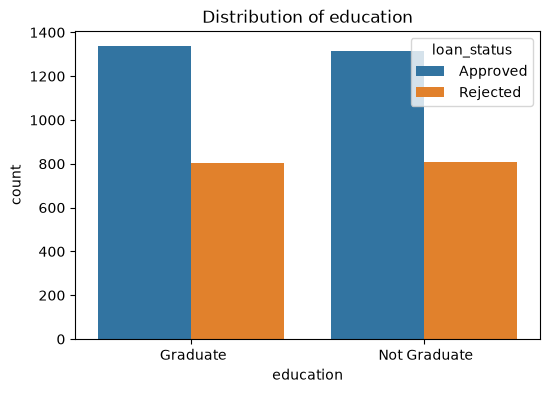

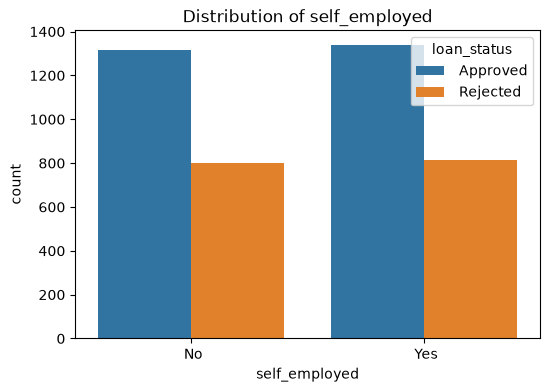

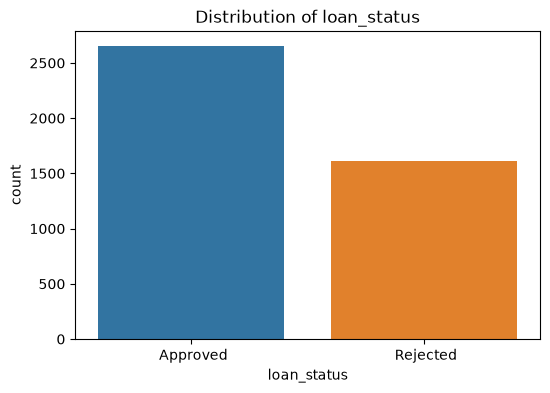

In [595]:
import matplotlib.pyplot as plt
import seaborn as sns

for col in str_cols:

    plt.figure(figsize=(6,4))

    sns.countplot(
        data=df,
        x=col,hue='loan_status'
    )

    plt.title(f"Distribution of {col}")
    plt.show()

In [596]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 4269 entries, 0 to 4268
Data columns (total 12 columns):
 #   Column                    Non-Null Count  Dtype
---  ------                    --------------  -----
 0   no_of_dependents          4269 non-null   int64
 1   education                 4269 non-null   str  
 2   self_employed             4269 non-null   str  
 3   income_annum              4269 non-null   int64
 4   loan_amount               4269 non-null   int64
 5   loan_term                 4269 non-null   int64
 6   cibil_score               4269 non-null   int64
 7   residential_assets_value  4269 non-null   int64
 8   commercial_assets_value   4269 non-null   int64
 9   luxury_assets_value       4269 non-null   int64
 10  bank_asset_value          4269 non-null   int64
 11  loan_status               4269 non-null   str  
dtypes: int64(9), str(3)
memory usage: 400.3 KB


In [597]:
str_cols = df.select_dtypes(include='str').columns.tolist()
numeric_cols = df.select_dtypes(include='number').columns.tolist()

In [598]:
str_cols

['education', 'self_employed', 'loan_status']

In [599]:
numeric_cols

['no_of_dependents',
 'income_annum',
 'loan_amount',
 'loan_term',
 'cibil_score',
 'residential_assets_value',
 'commercial_assets_value',
 'luxury_assets_value',
 'bank_asset_value']

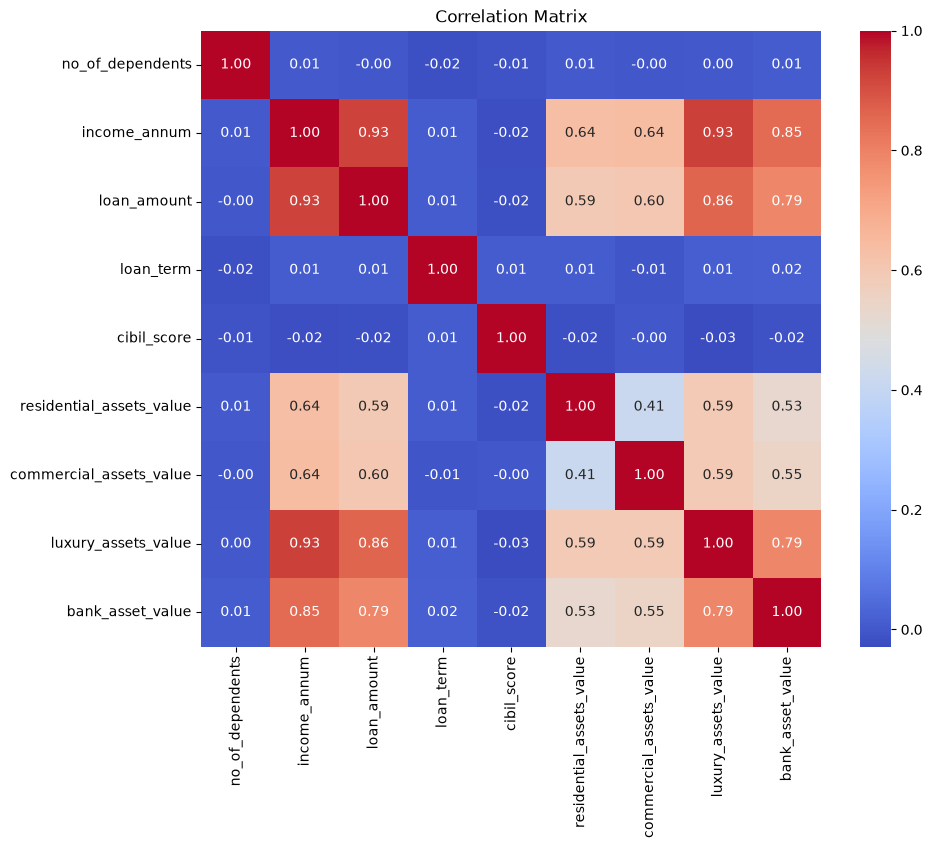

In [600]:
plt.figure(figsize=(10,8))
sns.heatmap(
    df[numeric_cols].corr(),
    annot=True,
    cmap='coolwarm',
    fmt='.2f'
)
plt.title('Correlation Matrix')
plt.show()

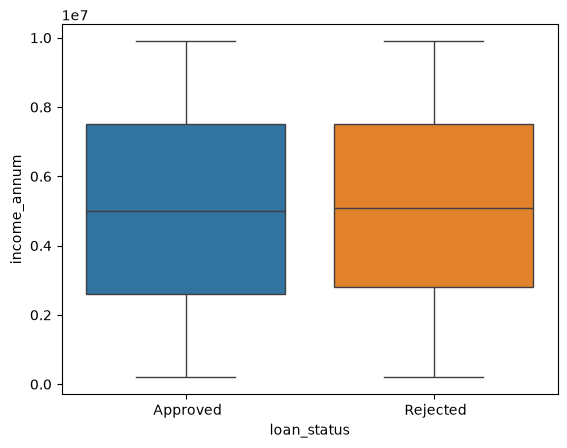

In [601]:
sns.boxplot(
    data=df,
    x='loan_status',
    y='income_annum',hue='loan_status'
)
plt.show()

In [602]:
df = df.drop('loan_id',axis=1)

KeyError: "['loan_id'] not found in axis"

In [ ]:
np.average(df['loan_term'])

In [ ]:
df.shape

In [ ]:
numeric_cols.remove('loan_id')

In [ ]:
df.columns

In [ ]:
str_cols

In [ ]:
average_income = np.round(np.mean(df['annual_income']))

In [ ]:
from num2words import num2words as n2w

In [ ]:
n2w(average_income)

In [ ]:
df.describe().transpose()

In [ ]:
df['annual_income'].min(),df['annual_income'].max()

In [ ]:
n2w(df['annual_income'].max())

In [ ]:
loan_term_mean = np.mean(df['loan_term'])

In [ ]:
f'Average loan years {n2w(round(loan_term_mean))} years'

In [ ]:
numeric_cols

In [ ]:
str_cols

In [ ]:
from sklearn.preprocessing import StandardScaler

In [ ]:
scaler = StandardScaler()

In [ ]:

encoded_str = pd.get_dummies(
    df[str_cols],
    columns=str_cols,
    drop_first=True
)



In [ ]:
df = pd.concat([scaled_numeric, encoded_str], axis=1)

In [ ]:
df

In [ ]:
from sklearn.model_selection import train_test_split

In [ ]:
X = df.drop('loan_status_ Rejected',axis=1)

In [ ]:
y = df['loan_status_ Rejected']

In [ ]:
X_train,X_test,y_train,y_test = train_test_split(X,y
                                                 ,test_size=0.2,random_state=42,stratify=y)